In [88]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

from abstract_values.utils.data import BIDS_FOLDER

sns.set_theme(style='ticks', font_scale=1.1)

In [89]:
# ── settings ───────────────────────────────────────────────────────────────
SUBJECTS  = ['pil01', 'pil02']
N_VOXELS  = 100      # default for most plots
NOISE     = 'full'
SMOOTHED  = False
LAMBD     = 0.1      # primary λ

DERIV_DIR = BIDS_FOLDER / 'derivatives' / 'decoding'

ROIS          = ['BensonV1', 'BensonV2', 'BensonV3', 'NPCl', 'NPCr']
SWEEP_ROIS    = ['BensonV1', 'NPCr']
N_VOXELS_GRID = [50, 100, 250, 500]
LAMBDA_GRID   = [0.0, 0.1]

MAPPING_PALETTE = {'cdf': 'steelblue', 'inverse_cdf': 'tomato'}


def get_mapping(subject, session):
    """Return 'cdf' or 'inverse_cdf' for this subject + session."""
    num = int(''.join(c for c in str(subject) if c.isdigit()))
    if num % 2 == 0:
        return 'cdf' if session == 1 else 'inverse_cdf'
    return 'inverse_cdf' if session == 1 else 'cdf'

In [90]:
def load_decoding(kind, subject, mask, n_voxels=N_VOXELS, noise=NOISE,
                  smoothed=SMOOTHED, lambd=LAMBD):
    """Load all available decoding TSVs; returns None if not found."""
    smooth_label = '_smoothed' if smoothed else ''
    lambd_label  = f'_lambda-{lambd}' if lambd != 0.0 else ''
    sub_dir = DERIV_DIR / kind / f'sub-{subject}'
    if not sub_dir.exists():
        return None

    def _load(fn):
        df = pd.read_csv(fn, sep='\t', index_col=list(range(4)))
        df.columns = df.columns.astype(float)
        return df

    dfs = []
    for sd in sorted(sub_dir.iterdir()):
        if not sd.is_dir():
            continue
        fn = (sd / 'func' /
              f'sub-{subject}_{sd.name}_mask-{mask}'
              f'_nvoxels-{n_voxels}_noise-{noise}{smooth_label}{lambd_label}_pars.tsv')
        if fn.exists():
            dfs.append(_load(fn))
    fn_all = (sub_dir / 'func' /
              f'sub-{subject}_mask-{mask}'
              f'_nvoxels-{n_voxels}_noise-{noise}{smooth_label}{lambd_label}_pars.tsv')
    if fn_all.exists():
        dfs.append(_load(fn_all))
    if not dfs:
        return None
    combined = pd.concat(dfs).sort_index()
    return combined[~combined.index.duplicated(keep='first')]


def normalize_rows(df):
    return df.div(df.sum(axis=1), axis=0)


def posterior_mean_orientation(df):
    """Circular mean of posterior (axial, period=π, columns in rad)."""
    cols = df.columns.values.astype(float)
    norm = normalize_rows(df).values
    return np.arctan2(norm @ np.sin(2 * cols), norm @ np.cos(2 * cols)) / 2 % np.pi


def posterior_mean_value(df):
    """Expected value of posterior (columns in CHF)."""
    return normalize_rows(df).values @ df.columns.values.astype(float)


def circular_error_deg(true_rad, pred_rad):
    diff = np.abs(true_rad - pred_rad) % np.pi
    return float(np.rad2deg(np.mean(np.where(diff > np.pi/2, np.pi - diff, diff))))


def circular_correlation(true_rad, pred_rad):
    """Mean of cos/sin Pearson r for axial orientations (doubled angles)."""
    t2, p2 = 2*true_rad, 2*pred_rad
    return float((np.corrcoef(np.cos(t2), np.cos(p2))[0,1] +
                  np.corrcoef(np.sin(t2), np.sin(p2))[0,1]) / 2)


def aggregate_posterior(df):
    """Align each trial to its true stimulus and return mean posterior."""
    norm = normalize_rows(df)
    cols = norm.columns.values.astype(float)
    true_vals = df.index.get_level_values(-1).astype(float)
    n = len(cols)
    aligned = np.zeros((len(norm), n))
    for i, (row, tv) in enumerate(zip(norm.values, true_vals)):
        ci = int(np.argmin(np.abs(cols - tv)))
        aligned[i] = np.roll(row, n // 2 - ci)
    step = cols[1] - cols[0]
    return (np.arange(n) - n // 2) * step, aligned.mean(axis=0)

## Build tidy DataFrames

In [91]:
# ── build long-form DataFrames for all plots ───────────────────────────────
rows_acc_gabor  = []
rows_acc_value  = []
rows_post_gabor = []
rows_post_value = []
rows_scat_gabor = []
rows_scat_value = []
rows_nvox       = []

for subject in SUBJECTS:
    for roi in ROIS:
        # ── default λ, default n_voxels: accuracy + scatter + posterior ────
        for kind in ['gabor', 'value']:
            df = load_decoding(kind, subject, roi)
            if df is None:
                continue
            for ses in sorted(df.index.get_level_values('session').unique()):
                ses_df  = df.xs(ses, level='session')
                mapping = get_mapping(subject, ses)
                base    = dict(subject=subject, roi=roi, session=ses, mapping=mapping)

                if kind == 'gabor':
                    true_rad = ses_df.index.get_level_values(
                        'true_orientation_rad').astype(float)
                    pred_rad = posterior_mean_orientation(ses_df)
                    rows_acc_gabor.append({**base,
                        'circ_err_deg': circular_error_deg(true_rad, pred_rad),
                        'circ_r':       circular_correlation(true_rad, pred_rad),
                    })
                    for true_d, pred_d in zip(np.rad2deg(true_rad), np.rad2deg(pred_rad)):
                        rows_scat_gabor.append({**base,
                            'true_deg': true_d, 'pred_deg': pred_d})

                    dev, post = aggregate_posterior(ses_df)
                    for d, p in zip(np.rad2deg(dev), post):
                        rows_post_gabor.append({**base, 'deviation': d, 'posterior': p})

                else:  # value
                    true_v = ses_df.index.get_level_values('true_value_chf').astype(float)
                    pred_v = posterior_mean_value(ses_df)
                    r, _   = pearsonr(true_v, pred_v)
                    rows_acc_value.append({**base,
                        'mae_chf': float(np.mean(np.abs(true_v - pred_v))), 'r': r})
                    for tv, pv in zip(true_v, pred_v):
                        rows_scat_value.append({**base, 'true_chf': tv, 'pred_chf': pv})

                    dev, post = aggregate_posterior(ses_df)
                    for d, p in zip(dev, post):
                        rows_post_value.append({**base, 'deviation': d, 'posterior': p})

        # ── n_voxels sweep: both λ, both kinds ────────────────────────────
        if roi in SWEEP_ROIS:
            for kind in ['gabor', 'value']:
                for nv in N_VOXELS_GRID:
                    for lam in LAMBDA_GRID:
                        df = load_decoding(kind, subject, roi, n_voxels=nv, lambd=lam)
                        if df is None:
                            continue
                        if kind == 'gabor':
                            true_v = df.index.get_level_values(
                                'true_orientation_rad').astype(float)
                            pred_v = posterior_mean_orientation(df)
                            err = circular_error_deg(true_v, pred_v)
                        else:
                            true_v = df.index.get_level_values(
                                'true_value_chf').astype(float)
                            pred_v = posterior_mean_value(df)
                            err = float(np.mean(np.abs(true_v - pred_v)))
                        rows_nvox.append(dict(subject=subject, roi=roi, kind=kind,
                                              n_voxels=nv, lambd=lam, err=err))

acc_gabor  = pd.DataFrame(rows_acc_gabor)
acc_value  = pd.DataFrame(rows_acc_value)
post_gabor = pd.DataFrame(rows_post_gabor)
post_value = pd.DataFrame(rows_post_value)
scat_gabor = pd.DataFrame(rows_scat_gabor)
scat_value = pd.DataFrame(rows_scat_value)
nvox_df    = pd.DataFrame(rows_nvox)

print(f'Gabor acc rows: {len(acc_gabor)},  Value acc rows: {len(acc_value)}')
print(f'n_voxels rows:  {len(nvox_df)}')

Gabor acc rows: 14,  Value acc rows: 11
n_voxels rows:  58


# Gabor orientation decoding

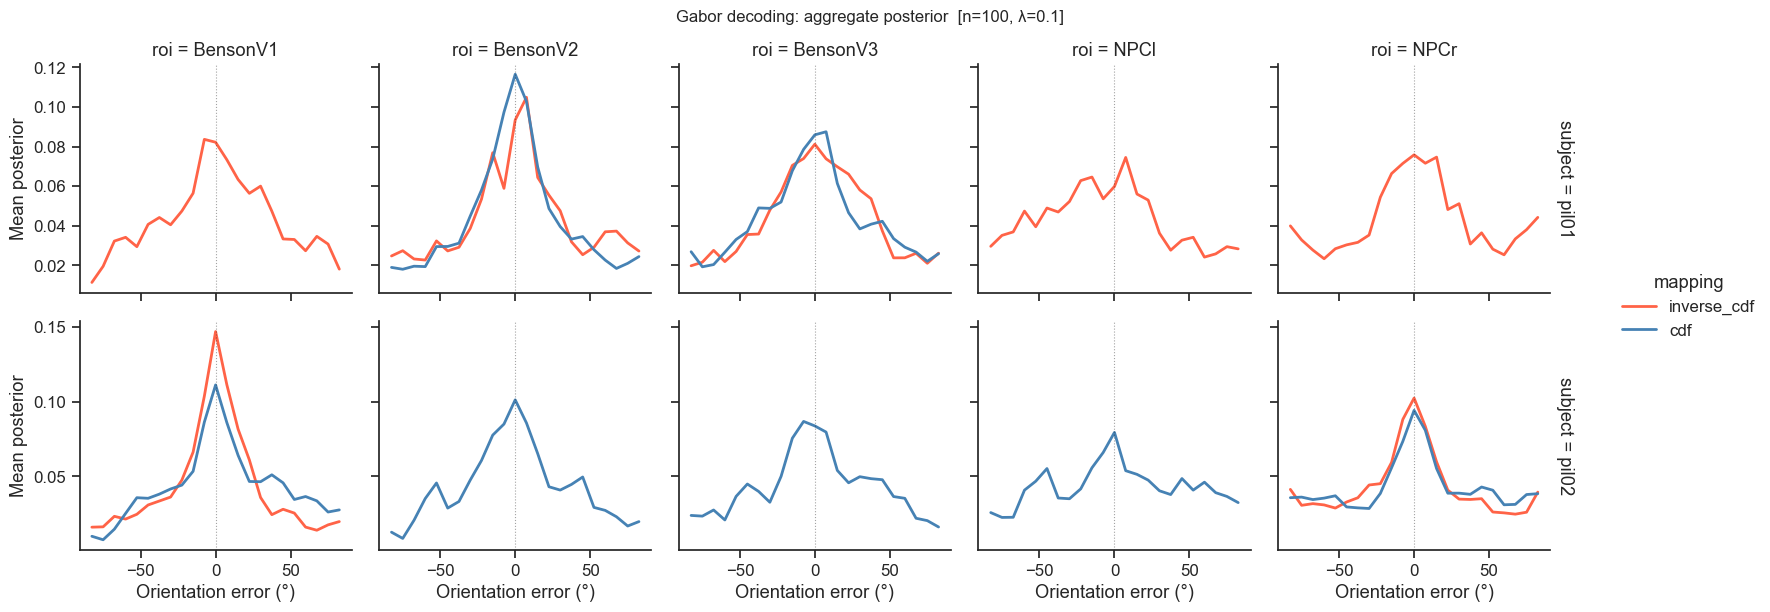

In [92]:
# ── aggregate posterior ────────────────────────────────────────────────────
g = sns.FacetGrid(post_gabor, row='subject', col='roi', hue='mapping',
                  palette=MAPPING_PALETTE, height=3, aspect=1.1,
                  sharey='row', margin_titles=True)
g.map(sns.lineplot, 'deviation', 'posterior', linewidth=2)
g.add_legend(title='mapping')
for ax in g.axes.flat:
    ax.axvline(0, color='k', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel('Orientation error (°)')
    ax.set_ylabel('Mean posterior')
g.figure.suptitle(
    f'Gabor decoding: aggregate posterior  [n={N_VOXELS}, λ={LAMBD}]',
    y=1.02, fontsize=12)
plt.show()

In [ ]:
# ── scatter: decoded vs. true orientation (col=roi, row=subject) ───────────
# hue = mapping; marker = session (to distinguish ses-1 vs ses-2)
markers = {1: 'o', 2: 's'}

g = sns.FacetGrid(scat_gabor, col='roi', row='subject', hue='mapping',
                  palette=MAPPING_PALETTE, height=3.5, aspect=1.0,
                  col_order=ROIS, margin_titles=True)
for ses, marker in markers.items():
    g.map_dataframe(sns.scatterplot, x='true_deg', y='pred_deg',
                    data=scat_gabor[scat_gabor['session'] == ses],
                    s=4, alpha=0.35, linewidth=0, marker=marker,
                    label=f'ses-{ses}')
g.add_legend(title='mapping')
for ax in g.axes.flat:
    ax.plot([0, 180], [0, 180], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(0, 180); ax.set_ylim(0, 180)
    ax.set_aspect('equal')
    ax.set_xlabel('True orientation (°)')
    ax.set_ylabel('Decoded orientation (°)')

# Annotate each panel with circular correlation
for (row_val, col_val), ax in g.axes_dict.items():
    sub_acc = acc_gabor[(acc_gabor['subject'] == row_val) & (acc_gabor['roi'] == col_val)]
    if not sub_acc.empty:
        mean_r = sub_acc['circ_r'].mean()
        ax.text(0.05, 0.95, f'r={mean_r:.2f}', transform=ax.transAxes,
                fontsize=9, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

g.figure.suptitle(
    f'Gabor decoding scatter  [n={N_VOXELS}, λ={LAMBD}]',
    y=1.02, fontsize=12)
plt.show()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22556/1054809030.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22556/1054809030.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


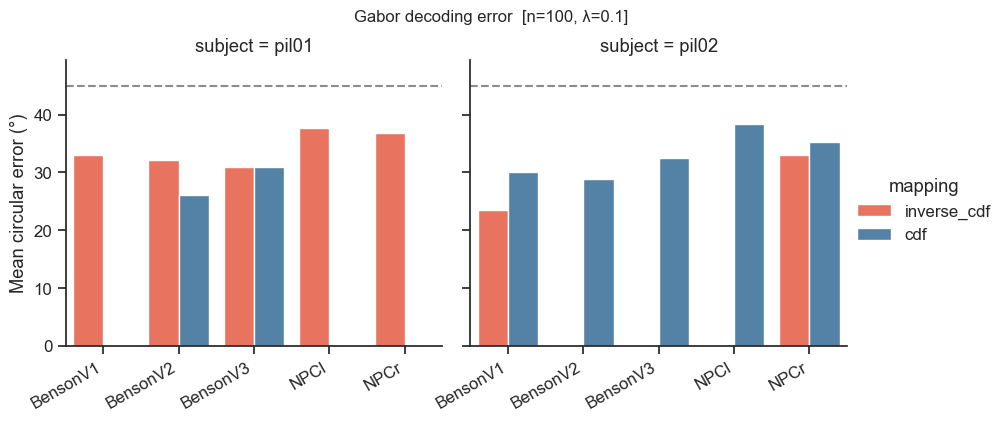

subject  session     mapping      roi  circ_err_deg   circ_r
  pil01        1 inverse_cdf BensonV1     33.000535 0.320393
  pil01        1 inverse_cdf BensonV2     32.220311 0.337387
  pil01        2         cdf BensonV2     26.184275 0.498032
  pil01        1 inverse_cdf BensonV3     30.876620 0.385540
  pil01        2         cdf BensonV3     30.897727 0.370809
  pil01        1 inverse_cdf     NPCl     37.728287 0.199388
  pil01        1 inverse_cdf     NPCr     36.741021 0.218726
  pil02        1         cdf BensonV1     30.040550 0.381086
  pil02        2 inverse_cdf BensonV1     23.553702 0.542738
  pil02        1         cdf BensonV2     28.926242 0.408013
  pil02        1         cdf BensonV3     32.430291 0.317649
  pil02        1         cdf     NPCl     38.321908 0.168895
  pil02        1         cdf     NPCr     35.330662 0.258829
  pil02        2 inverse_cdf     NPCr     32.977965 0.329477


In [94]:
# ── accuracy: circular error bar chart ────────────────────────────────────
CHANCE_DEG = 45.0
g = sns.catplot(data=acc_gabor, x='roi', y='circ_err_deg',
                hue='mapping', col='subject', kind='bar',
                palette=MAPPING_PALETTE, height=4, aspect=1.1,
                order=ROIS, errorbar=None)
for ax in g.axes.flat:
    ax.axhline(CHANCE_DEG, color='k', lw=1.5, ls='--', alpha=0.5,
               label=f'chance ({CHANCE_DEG:.0f}°)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel('Mean circular error (°)')
    ax.set_ylim(0, CHANCE_DEG * 1.1)
g.figure.suptitle(
    f'Gabor decoding error  [n={N_VOXELS}, λ={LAMBD}]',
    y=1.02, fontsize=12)
plt.show()

print(acc_gabor[['subject','session','mapping','roi','circ_err_deg','circ_r']].to_string(index=False))

## Circular correlation by ROI and n_voxels

In [ ]:
# ── circular correlation swarmplot (gabor, default n_voxels) ──────────────
# One dot per participant (averaged across sessions)
acc_gabor_subj = acc_gabor.groupby(['subject', 'roi'], as_index=False)['circ_r'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.swarmplot(data=acc_gabor_subj, x='roi', y='circ_r',
              order=ROIS, dodge=False, color='0.3',
              size=6, ax=ax)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('')
ax.set_ylabel('Circular correlation (r)')
ax.set_title(f'Gabor decoding: circular correlation  [n={N_VOXELS}, λ={LAMBD}]')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# ── circular correlation by n_voxels (gabor only, sweep ROIs) ─────────────
rows_nvox_circ = []
for subject in SUBJECTS:
    for roi in SWEEP_ROIS:
        for nv in N_VOXELS_GRID:
            for lam in LAMBDA_GRID:
                df = load_decoding('gabor', subject, roi, n_voxels=nv, lambd=lam)
                if df is None:
                    continue
                true_v = df.index.get_level_values('true_orientation_rad').astype(float)
                pred_v = posterior_mean_orientation(df)
                rows_nvox_circ.append(dict(
                    subject=subject, roi=roi, n_voxels=nv, lambd=lam,
                    circ_r=circular_correlation(true_v, pred_v)))

nvox_circ = pd.DataFrame(rows_nvox_circ)

if not nvox_circ.empty:
    nvox_circ['n_voxels_str'] = nvox_circ['n_voxels'].astype(str)
    nvox_circ['λ'] = nvox_circ['lambd'].astype(str)

    g = sns.catplot(data=nvox_circ, x='n_voxels_str', y='circ_r',
                    hue='λ', col='roi', kind='swarm',
                    palette={'0.0': 'tomato', '0.1': 'steelblue'},
                    col_order=SWEEP_ROIS, height=4, aspect=1.0,
                    dodge=True, size=5)
    for ax in g.axes.flat:
        ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
        ax.set_xlabel('n_voxels')
        ax.set_ylabel('Circular correlation (r)')
    g.figure.suptitle('Gabor circular correlation by n_voxels', y=1.02, fontsize=12)
    plt.show()
else:
    print('No n_voxels sweep data for gabor circ_r.')

# Abstract value decoding

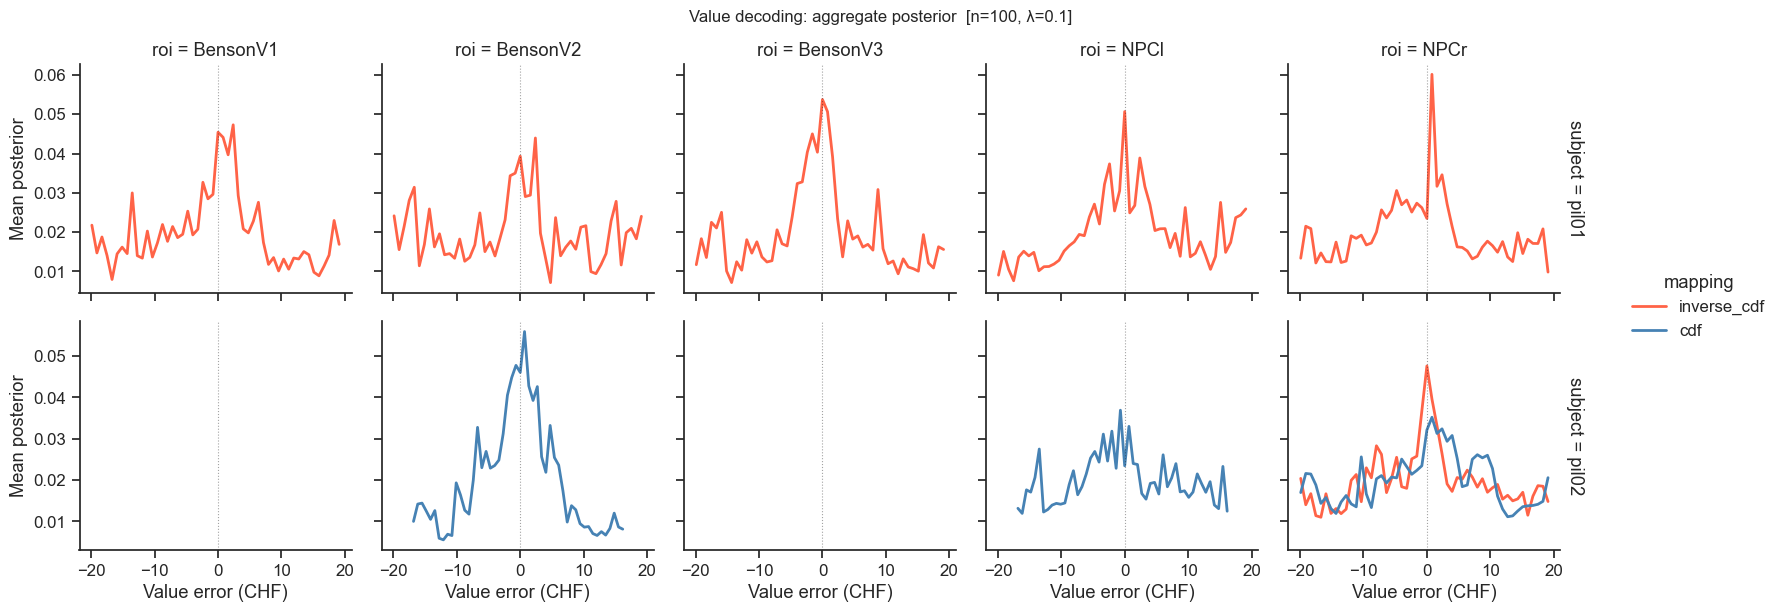

In [95]:
# ── aggregate posterior ────────────────────────────────────────────────────
g = sns.FacetGrid(post_value, row='subject', col='roi', hue='mapping',
                  palette=MAPPING_PALETTE, height=3, aspect=1.1,
                  sharey='row', margin_titles=True)
g.map(sns.lineplot, 'deviation', 'posterior', linewidth=2)
g.add_legend(title='mapping')
for ax in g.axes.flat:
    ax.axvline(0, color='k', lw=0.8, ls=':', alpha=0.4)
    ax.set_xlabel('Value error (CHF)')
    ax.set_ylabel('Mean posterior')
g.figure.suptitle(
    f'Value decoding: aggregate posterior  [n={N_VOXELS}, λ={LAMBD}]',
    y=1.02, fontsize=12)
plt.show()

In [ ]:
# ── scatter: decoded vs. true value (col=roi, row=subject) ────────────────
# hue = mapping; marker = session (circle=ses-1, square=ses-2)
markers = {1: 'o', 2: 's'}

g = sns.FacetGrid(scat_value, col='roi', row='subject', hue='mapping',
                  palette=MAPPING_PALETTE, height=3.5, aspect=1.0,
                  col_order=ROIS, margin_titles=True)
for ses, marker in markers.items():
    g.map_dataframe(sns.scatterplot, x='true_chf', y='pred_chf',
                    data=scat_value[scat_value['session'] == ses],
                    s=3, alpha=0.3, linewidth=0, marker=marker,
                    label=f'ses-{ses}')
g.add_legend(title='mapping')
for ax in g.axes.flat:
    ax.plot([2, 42], [2, 42], 'k--', lw=1, alpha=0.5)
    ax.set_xlim(2, 42); ax.set_ylim(2, 42)
    ax.set_aspect('equal')
    ax.set_xlabel('True value (CHF)')
    ax.set_ylabel('Decoded value (CHF)')

# Annotate each panel with Pearson r
for (row_val, col_val), ax in g.axes_dict.items():
    sub_acc = acc_value[(acc_value['subject'] == row_val) & (acc_value['roi'] == col_val)]
    if not sub_acc.empty:
        mean_r = sub_acc['r'].mean()
        ax.text(0.05, 0.95, f'r={mean_r:.2f}', transform=ax.transAxes,
                fontsize=9, va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

g.figure.suptitle(
    f'Value decoding scatter  [n={N_VOXELS}, λ={LAMBD}]',
    y=1.02, fontsize=12)
plt.show()

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22556/2161369330.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_22556/2161369330.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')


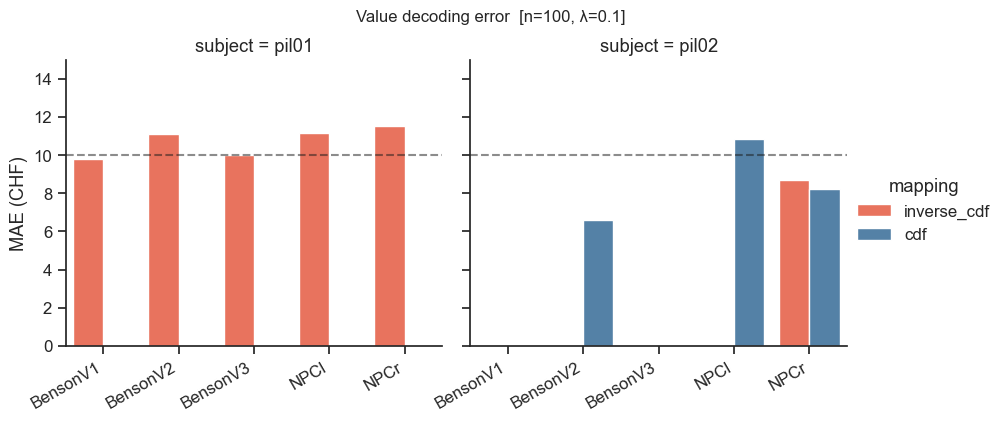

subject  session     mapping      roi   mae_chf         r
  pil01        1 inverse_cdf BensonV1  9.772984  0.296353
  pil01        1 inverse_cdf BensonV2 11.095918  0.120941
  pil01        1 inverse_cdf BensonV3  9.994757  0.223007
  pil01        1 inverse_cdf     NPCl 11.156751  0.067755
  pil01        1 inverse_cdf     NPCr 11.524426  0.020647
  pil02        1         cdf BensonV1       NaN       NaN
  pil02        2 inverse_cdf BensonV1       NaN       NaN
  pil02        1         cdf BensonV2  6.581010  0.545019
  pil02        1         cdf     NPCl 10.856128 -0.044829
  pil02        1         cdf     NPCr  8.226563  0.337497
  pil02        2 inverse_cdf     NPCr  8.711725  0.499820


In [97]:
# ── accuracy: MAE bar chart ────────────────────────────────────────────────
CHANCE_CHF = 10.0
g = sns.catplot(data=acc_value, x='roi', y='mae_chf',
                hue='mapping', col='subject', kind='bar',
                palette=MAPPING_PALETTE, height=4, aspect=1.1,
                order=ROIS, errorbar=None)
for ax in g.axes.flat:
    ax.axhline(CHANCE_CHF, color='k', lw=1.5, ls='--', alpha=0.5)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.set_xlabel('')
    ax.set_ylabel('MAE (CHF)')
    ax.set_ylim(0, CHANCE_CHF * 1.5)
g.figure.suptitle(
    f'Value decoding error  [n={N_VOXELS}, λ={LAMBD}]',
    y=1.02, fontsize=12)
plt.show()

print(acc_value[['subject','session','mapping','roi','mae_chf','r']].to_string(index=False))

In [ ]:
# ── Pearson r swarmplot (value decoding, default n_voxels) ────────────────
# One dot per participant (averaged across sessions)
acc_value_subj = acc_value.groupby(['subject', 'roi'], as_index=False)['r'].mean()

fig, ax = plt.subplots(figsize=(6, 4))
sns.swarmplot(data=acc_value_subj, x='roi', y='r',
              order=ROIS, dodge=False, color='0.3',
              size=6, ax=ax)
ax.axhline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.set_xlabel('')
ax.set_ylabel('Pearson r')
ax.set_title(f'Value decoding: correlation  [n={N_VOXELS}, λ={LAMBD}]')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

# Effect of n_voxels  (λ as hue)

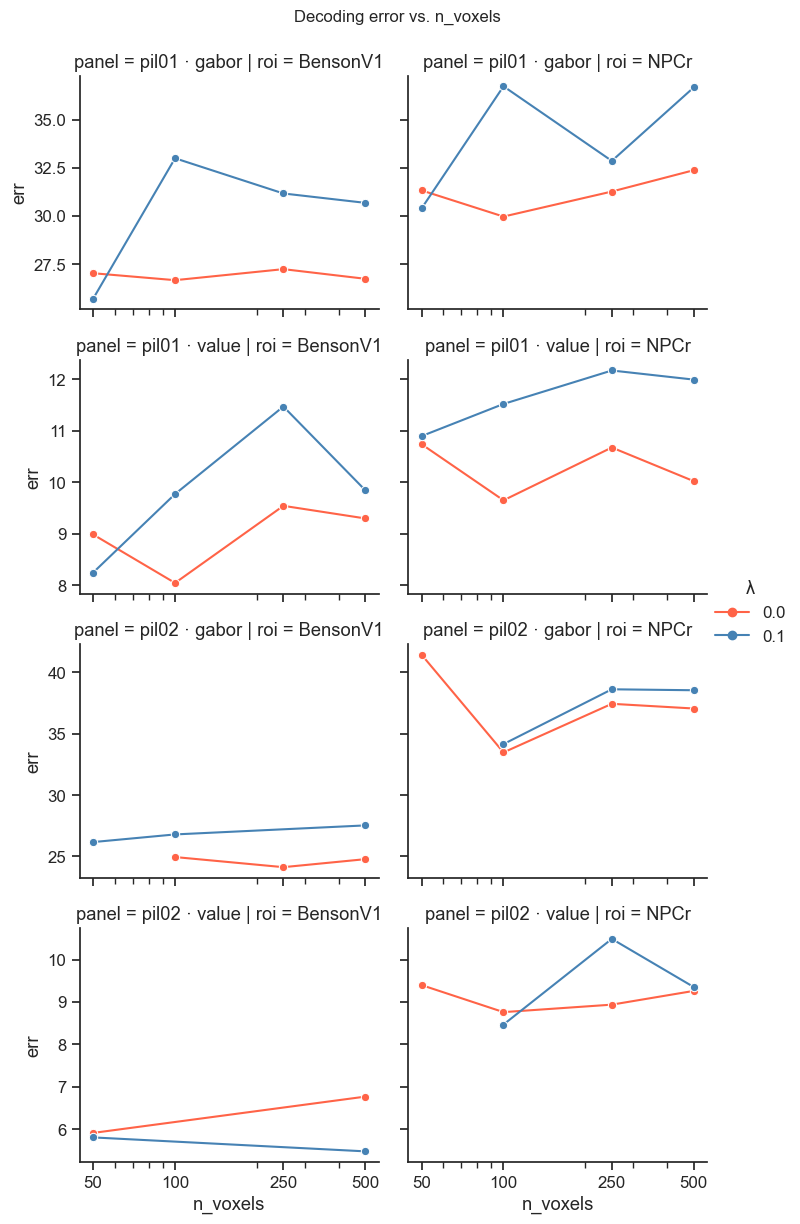

In [98]:
# ── n_voxels sweep: hue=λ, col=roi, row=kind+subject ─────────────────────
if nvox_df.empty:
    print('No n_voxels data yet — jobs still running.')
else:
    nvox_df['λ'] = nvox_df['lambd'].astype(str)
    nvox_df['panel'] = nvox_df['subject'] + ' · ' + nvox_df['kind']

    units = {'gabor': 'Circular error (°)', 'value': 'MAE (CHF)'}
    nvox_df['err_label'] = nvox_df['kind'].map(units)

    g = sns.relplot(data=nvox_df, x='n_voxels', y='err',
                    hue='λ', col='roi', row='panel',
                    kind='line', marker='o',
                    palette={str(l): c for l, c in zip([0.0, 0.1], ['tomato', 'steelblue'])},
                    height=3, aspect=1.2, facet_kws={'sharey': 'row'})
    g.set(xscale='log')
    for ax in g.axes.flat:
        ax.set_xticks(N_VOXELS_GRID)
        ax.set_xticklabels(N_VOXELS_GRID)
        ax.set_xlabel('n_voxels')
    g.figure.suptitle('Decoding error vs. n_voxels', y=1.02, fontsize=12)
    plt.show()

# λ comparison: aggregate posteriors

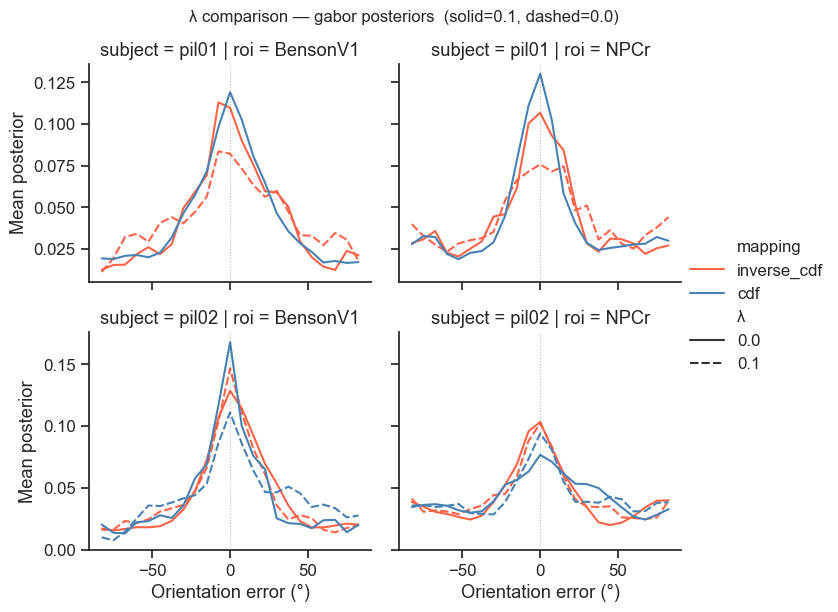

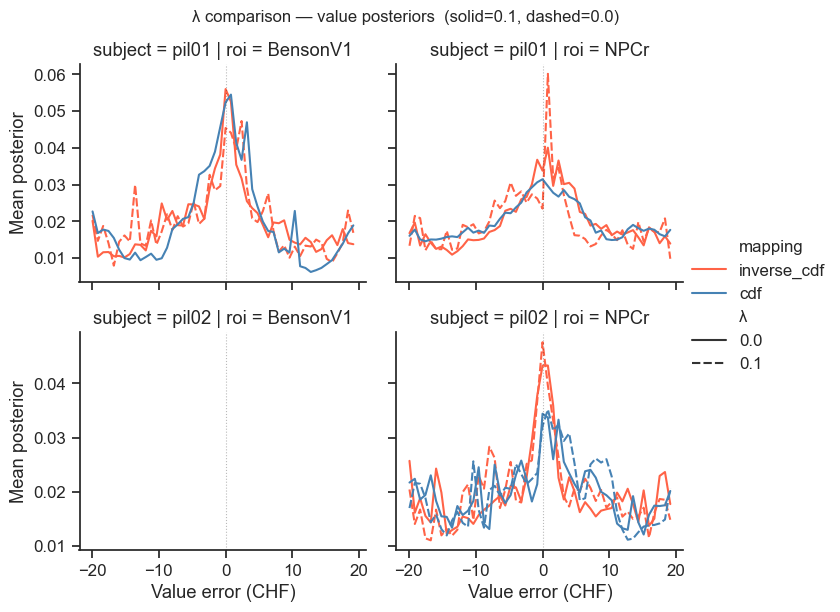

In [99]:
# ── build λ-comparison posteriors (BensonV1 + NPCr, both kinds) ───────────
rows_lam = []
for subject in SUBJECTS:
    for roi in SWEEP_ROIS:
        for kind in ['gabor', 'value']:
            for lam in LAMBDA_GRID:
                df = load_decoding(kind, subject, roi, lambd=lam)
                if df is None:
                    continue
                for ses in sorted(df.index.get_level_values('session').unique()):
                    ses_df  = df.xs(ses, level='session')
                    mapping = get_mapping(subject, ses)
                    dev, post = aggregate_posterior(ses_df)
                    x_axis = np.rad2deg(dev) if kind == 'gabor' else dev
                    for d, p in zip(x_axis, post):
                        rows_lam.append(dict(subject=subject, roi=roi, kind=kind,
                                             session=ses, mapping=mapping,
                                             lambd=lam, deviation=d, posterior=p))

lam_post = pd.DataFrame(rows_lam)
if lam_post.empty:
    print('No λ comparison data yet.')
else:
    lam_post['λ'] = lam_post['lambd'].astype(str)

    xlabels = {'gabor': 'Orientation error (°)', 'value': 'Value error (CHF)'}
    for kind, xlabel in xlabels.items():
        sub_df = lam_post[lam_post['kind'] == kind]
        if sub_df.empty:
            continue
        g = sns.relplot(data=sub_df, x='deviation', y='posterior',
                        hue='mapping', style='λ', col='roi', row='subject',
                        kind='line', palette=MAPPING_PALETTE,
                        col_order=SWEEP_ROIS,
                        height=3, aspect=1.2, facet_kws={'sharey': 'row'})
        for ax in g.axes.flat:
            ax.axvline(0, color='k', lw=0.8, ls=':', alpha=0.3)
        g.set(xlabel=xlabel, ylabel='Mean posterior')
        g.figure.suptitle(
            f'λ comparison — {kind} posteriors  (solid=0.1, dashed=0.0)',
            y=1.02, fontsize=12)
        plt.show()